Se creó el archivo de ejemplo: transacciones.csv

RESULTADOS DEL MODELO
Exactitud general: 71.60%
Precisión de fraude: 64.00%
Recall de fraude: 75.47%
F1-score de fraude: 69.26%

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

   No fraude       0.79      0.69      0.74       144
      Fraude       0.64      0.75      0.69       106

    accuracy                           0.72       250
   macro avg       0.72      0.72      0.71       250
weighted avg       0.73      0.72      0.72       250

MATRIZ DE CONFUSIÓN
                Predicho no fraude  Predicho fraude
Real no fraude                  99               45
Real fraude                     26               80

IMPORTANCIA DE LAS CARACTERÍSTICAS
            caracteristica  importancia
    distancia_ubicacion_km     0.242893
                     monto     0.206891
cantidad_transacciones_dia     0.189409
         es_comercio_nuevo     0.149193
         dispositivo_nuevo     0.120449
                 

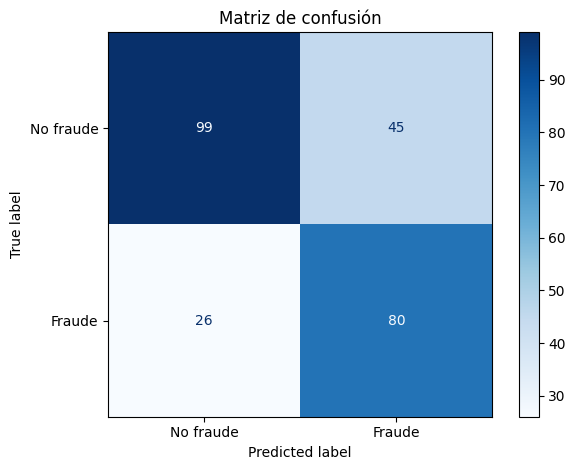

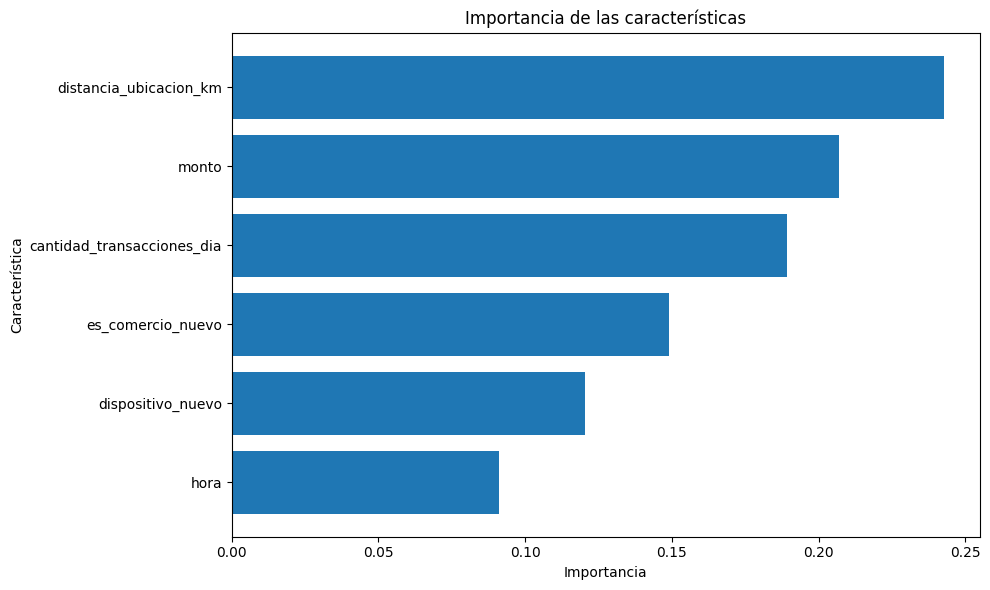

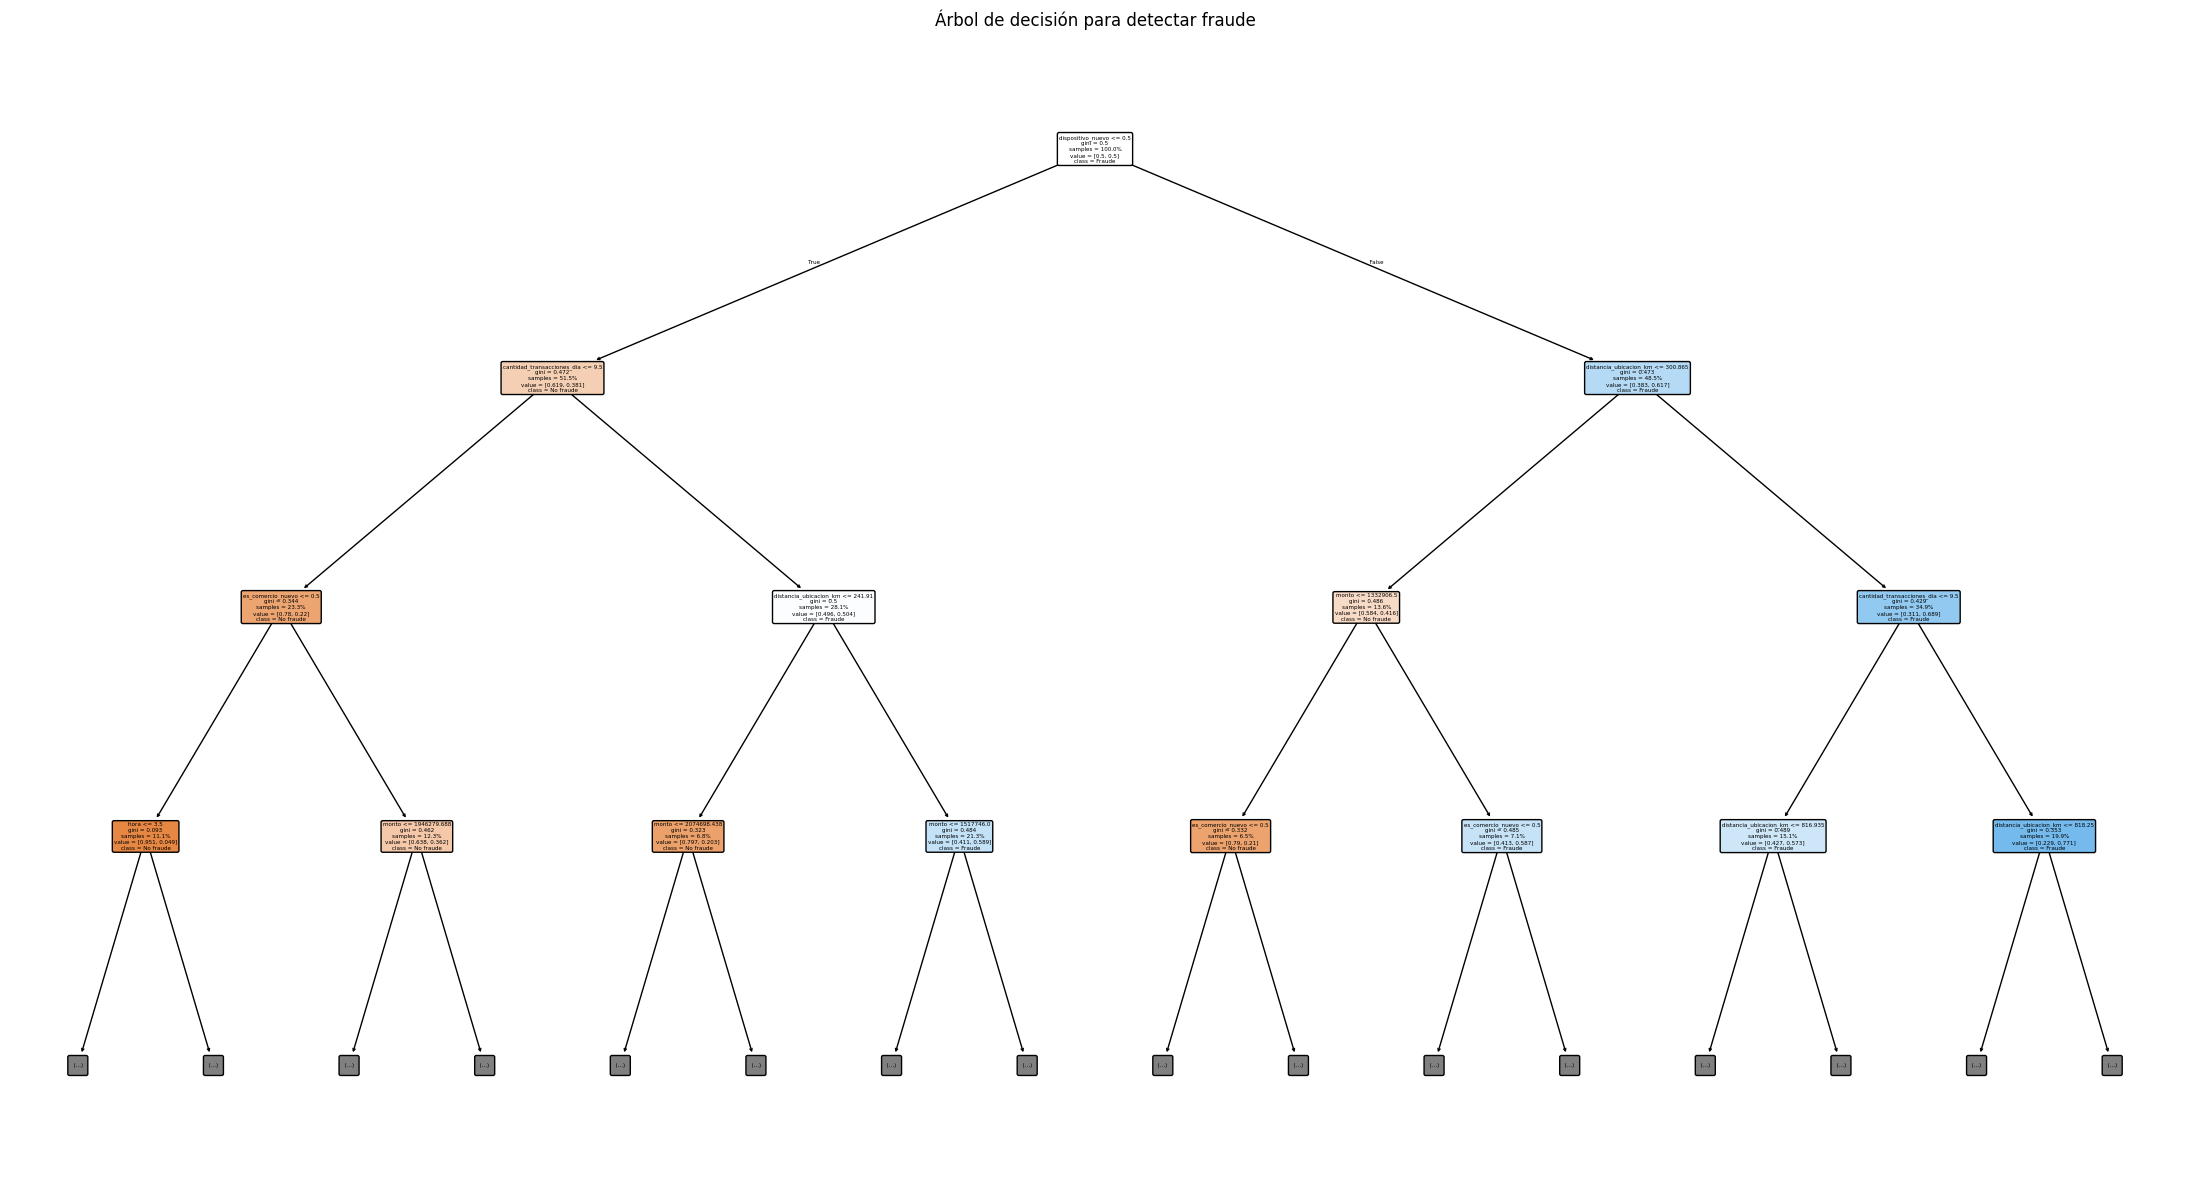

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ==========================================
# 1. Configuración
# ==========================================

ARCHIVO_DATOS = "transacciones.csv"
ARCHIVO_MODELO = "modelo_deteccion_fraude.pkl"

COLUMNAS_ENTRADA = [
    "monto",
    "hora",
    "distancia_ubicacion_km",
    "cantidad_transacciones_dia",
    "es_comercio_nuevo",
    "dispositivo_nuevo"
]

COLUMNA_OBJETIVO = "fraude"


# ==========================================
# 2. Crear datos de ejemplo
# ==========================================

if not os.path.exists(ARCHIVO_DATOS):
    np.random.seed(42)

    cantidad = 1000

    monto = np.random.uniform(
        10000,
        3000000,
        cantidad
    )

    hora = np.random.randint(
        0,
        24,
        cantidad
    )

    distancia = np.random.uniform(
        0,
        1000,
        cantidad
    )

    transacciones_dia = np.random.randint(
        1,
        20,
        cantidad
    )

    comercio_nuevo = np.random.randint(
        0,
        2,
        cantidad
    )

    dispositivo_nuevo = np.random.randint(
        0,
        2,
        cantidad
    )

    riesgo = (
        (monto > 1500000).astype(int)
        + (distancia > 300).astype(int)
        + ((hora < 5) | (hora > 23)).astype(int)
        + (transacciones_dia > 10).astype(int)
        + comercio_nuevo
        + dispositivo_nuevo
    )

    probabilidad_fraude = np.where(
        riesgo >= 3,
        0.65,
        0.03
    )

    fraude = np.random.binomial(
        1,
        probabilidad_fraude
    )

    datos_ejemplo = pd.DataFrame({
        "transaccion_id": range(1, cantidad + 1),
        "monto": monto.round(2),
        "hora": hora,
        "distancia_ubicacion_km": distancia.round(2),
        "cantidad_transacciones_dia": transacciones_dia,
        "es_comercio_nuevo": comercio_nuevo,
        "dispositivo_nuevo": dispositivo_nuevo,
        "fraude": fraude
    })

    datos_ejemplo.to_csv(
        ARCHIVO_DATOS,
        index=False,
        encoding="utf-8"
    )

    print(f"Se creó el archivo de ejemplo: {ARCHIVO_DATOS}")


# ==========================================
# 3. Cargar los datos
# ==========================================

try:
    datos = pd.read_csv(
        ARCHIVO_DATOS,
        encoding="utf-8"
    )
except FileNotFoundError:
    print(f"No se encontró el archivo '{ARCHIVO_DATOS}'.")
    exit()


columnas_requeridas = COLUMNAS_ENTRADA + [
    COLUMNA_OBJETIVO
]

if not all(
    columna in datos.columns
    for columna in columnas_requeridas
):
    print("El archivo CSV debe contener estas columnas:")
    print(", ".join(columnas_requeridas))
    exit()


# ==========================================
# 4. Limpiar y preparar los datos
# ==========================================

datos = datos.dropna(
    subset=columnas_requeridas
).copy()

for columna in columnas_requeridas:
    datos[columna] = pd.to_numeric(
        datos[columna],
        errors="coerce"
    )

datos = datos.dropna(
    subset=columnas_requeridas
).reset_index(drop=True)

datos[COLUMNA_OBJETIVO] = datos[
    COLUMNA_OBJETIVO
].astype(int)

if datos[COLUMNA_OBJETIVO].nunique() < 2:
    print("La columna fraude debe contener las clases 0 y 1.")
    exit()


X = datos[COLUMNAS_ENTRADA]
y = datos[COLUMNA_OBJETIVO]


# ==========================================
# 5. Separar entrenamiento y prueba
# ==========================================

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = (
    train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )
)


# ==========================================
# 6. Crear y entrenar el árbol
# ==========================================

modelo = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

modelo.fit(
    X_entrenamiento,
    y_entrenamiento
)


# ==========================================
# 7. Evaluar el modelo
# ==========================================

predicciones = modelo.predict(X_prueba)

precision_general = accuracy_score(
    y_prueba,
    predicciones
)

precision_fraude = precision_score(
    y_prueba,
    predicciones,
    pos_label=1,
    zero_division=0
)

recall_fraude = recall_score(
    y_prueba,
    predicciones,
    pos_label=1,
    zero_division=0
)

f1_fraude = f1_score(
    y_prueba,
    predicciones,
    pos_label=1,
    zero_division=0
)

print("\nRESULTADOS DEL MODELO")
print("=====================")
print(f"Exactitud general: {precision_general:.2%}")
print(f"Precisión de fraude: {precision_fraude:.2%}")
print(f"Recall de fraude: {recall_fraude:.2%}")
print(f"F1-score de fraude: {f1_fraude:.2%}")

print("\nREPORTE DE CLASIFICACIÓN")
print("========================")
print(
    classification_report(
        y_prueba,
        predicciones,
        target_names=["No fraude", "Fraude"],
        zero_division=0
    )
)


# ==========================================
# 8. Matriz de confusión
# ==========================================

matriz = confusion_matrix(
    y_prueba,
    predicciones,
    labels=[0, 1]
)

print("MATRIZ DE CONFUSIÓN")
print("===================")
print(
    pd.DataFrame(
        matriz,
        index=["Real no fraude", "Real fraude"],
        columns=["Predicho no fraude", "Predicho fraude"]
    )
)


# ==========================================
# 9. Importancia de las características
# ==========================================

importancias = pd.DataFrame({
    "caracteristica": COLUMNAS_ENTRADA,
    "importancia": modelo.feature_importances_
}).sort_values(
    by="importancia",
    ascending=False
)

print("\nIMPORTANCIA DE LAS CARACTERÍSTICAS")
print("==================================")
print(importancias.to_string(index=False))


# ==========================================
# 10. Guardar el modelo
# ==========================================

modelo_guardado = {
    "modelo": modelo,
    "columnas": COLUMNAS_ENTRADA
}

joblib.dump(
    modelo_guardado,
    ARCHIVO_MODELO
)

print(f"\nModelo guardado como: {ARCHIVO_MODELO}")


# ==========================================
# 11. Predecir una nueva transacción
# ==========================================

print("\nANALIZAR NUEVA TRANSACCIÓN")
print("==========================")

try:
    monto = float(input("Monto de la transacción: "))
    hora = int(input("Hora de la transacción (0-23): "))
    distancia = float(
        input("Distancia desde ubicación habitual (km): ")
    )
    transacciones_dia = int(
        input("Cantidad de transacciones del día: ")
    )
    comercio_nuevo = int(
        input("¿El comercio es nuevo? (0=No, 1=Sí): ")
    )
    dispositivo_nuevo = int(
        input("¿El dispositivo es nuevo? (0=No, 1=Sí): ")
    )
except ValueError:
    print("Debes ingresar valores numéricos válidos.")
    exit()


nueva_transaccion = pd.DataFrame({
    "monto": [monto],
    "hora": [hora],
    "distancia_ubicacion_km": [distancia],
    "cantidad_transacciones_dia": [transacciones_dia],
    "es_comercio_nuevo": [comercio_nuevo],
    "dispositivo_nuevo": [dispositivo_nuevo]
})


prediccion = modelo.predict(
    nueva_transaccion
)[0]

probabilidades = modelo.predict_proba(
    nueva_transaccion
)[0]

probabilidad_no_fraude = probabilidades[0]
probabilidad_fraude = probabilidades[1]

print("\nRESULTADO DEL ANÁLISIS")
print("======================")

if prediccion == 1:
    print("Resultado: POSIBLE FRAUDE")
else:
    print("Resultado: TRANSACCIÓN PROBABLEMENTE LEGÍTIMA")

print(f"Probabilidad de no fraude: {probabilidad_no_fraude:.2%}")
print(f"Probabilidad de fraude: {probabilidad_fraude:.2%}")


# ==========================================
# 12. Visualizar matriz de confusión
# ==========================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["No fraude", "Fraude"]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()


# ==========================================
# 13. Visualizar importancia de variables
# ==========================================

plt.figure(figsize=(10, 6))

plt.barh(
    importancias["caracteristica"],
    importancias["importancia"]
)

plt.xlabel("Importancia")
plt.ylabel("Característica")
plt.title("Importancia de las características")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# ==========================================
# 14. Visualizar el árbol de decisión
# ==========================================

plt.figure(figsize=(22, 12))

plot_tree(
    modelo,
    feature_names=COLUMNAS_ENTRADA,
    class_names=["No fraude", "Fraude"],
    filled=True,
    rounded=True,
    proportion=True,
    max_depth=3
)

plt.title("Árbol de decisión para detectar fraude")
plt.tight_layout()
plt.show()